In [1]:
import math
import numpy as np
import torch
import sys
import torch.nn as nn
import torch.nn.functional as F
from timeit import default_timer
import sys
import os
sys.path.append("../../")
from utility.adam import Adam
from utility.losses import LpLoss
from utility.normalizer import UnitGaussianNormalizer
from pcno.geo_utility import compute_edge_gradient_weights

In [2]:

equal_weights = False
data_path = "../../data/holeEtching/"
data = np.load(data_path+"pcno_data.npz")
nnodes, node_mask, nodes = data["nnodes"], data["node_mask"], data["nodes"]
node_weights = data["node_equal_weights"] if equal_weights else data["node_weights"]
directed_edges, edge_gradient_weights = data["directed_edges"], data["edge_gradient_weights"]
features = data["features"]
node_measures = data["node_measures"]
node_measures_raw = data["node_measures_raw"]
indices = np.isfinite(node_measures_raw)
node_rhos = np.copy(node_weights)
node_rhos[indices] = node_rhos[indices]/node_measures[indices]

# x,y,"holeRadius","ionFlux","etchantFlux","oxygenFlux","meanEnergy","sigmaEnergy"
features /= np.array([1,1,1,1,1,1,1,1.0,10,4.5e3,8e2,100,10])
nnodes = torch.from_numpy(nnodes)
node_mask = torch.from_numpy(node_mask)
nodes = torch.from_numpy(nodes.astype(np.float32))
node_weights = torch.from_numpy(node_weights.astype(np.float32))
node_rhos = torch.from_numpy(node_rhos.astype(np.float32))
features = torch.from_numpy(features.astype(np.float32))
directed_edges = torch.from_numpy(directed_edges.astype(np.int64))
edge_gradient_weights = torch.from_numpy(edge_gradient_weights.astype(np.float32))

# print(nodes)

nodes_input = nodes.clone()
N = nnodes.shape[0]
x_all = torch.cat((features[:,:,[6,7,8,9,10,11,12]],nodes_input, node_rhos), -1)
aux_all = (node_mask,  nodes,  node_weights,  directed_edges,  edge_gradient_weights)
y_all = features[:, :, [0,1,2,3,4,5]]
print('x_all.shape: ',x_all.shape,' y_all.shape: ',y_all.shape , 'node_mask.shape: ',node_mask.shape)
all_tuple = (x_all,y_all,node_mask,nodes,node_weights,directed_edges,edge_gradient_weights)


normalization_x = False
normalization_y = False
normalization_dim_x = []
normalization_dim_y = []
non_normalized_dim_x = 1
non_normalized_dim_y = 0

config = {"train" : {"normalization_x": normalization_x,"normalization_y": normalization_y, 
                     "normalization_dim_x": normalization_dim_x, "normalization_dim_y": normalization_dim_y, 
                     "non_normalized_dim_x": non_normalized_dim_x, "non_normalized_dim_y": non_normalized_dim_y}
                     }

x_all.shape:  torch.Size([4200, 171, 9])  y_all.shape:  torch.Size([4200, 171, 6]) node_mask.shape:  torch.Size([4200, 171, 1])


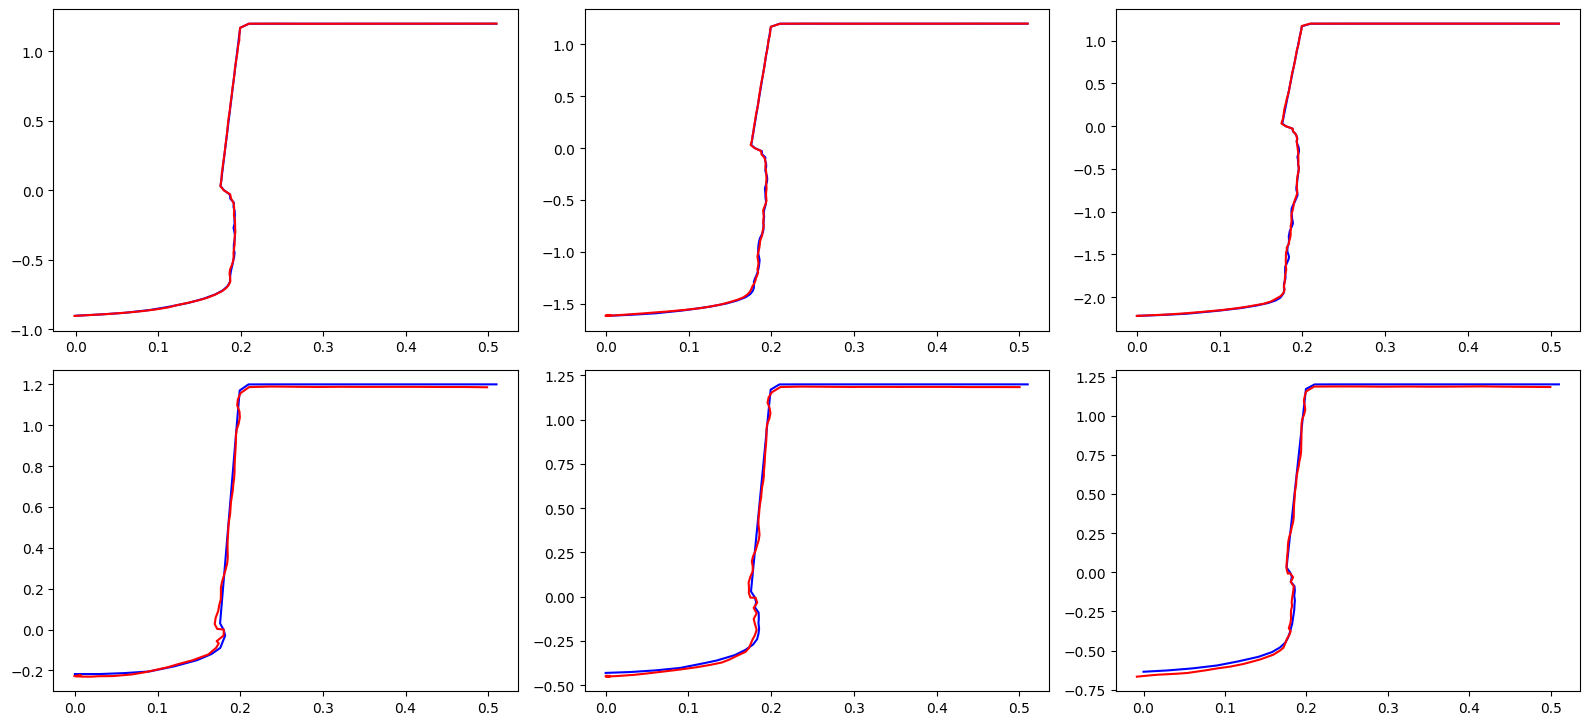

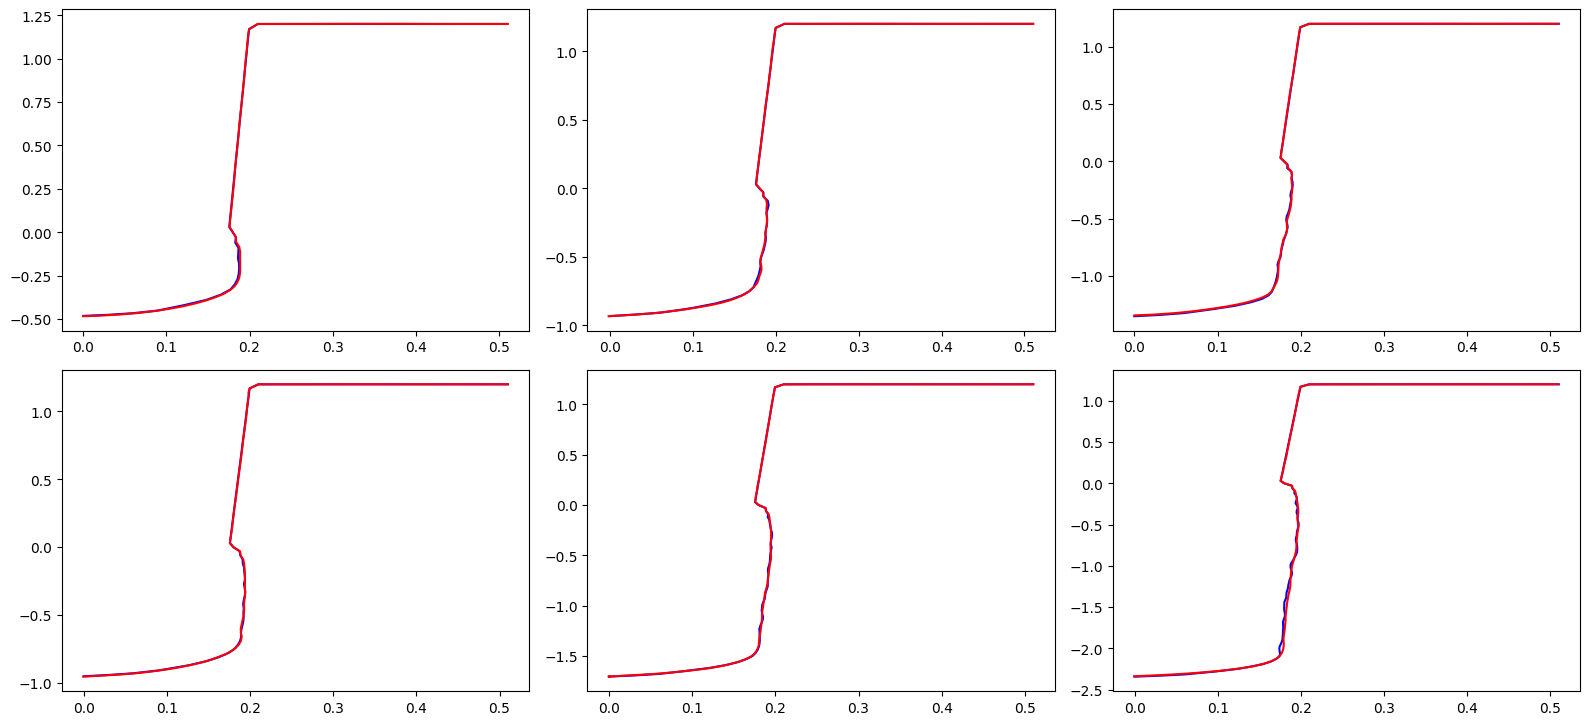

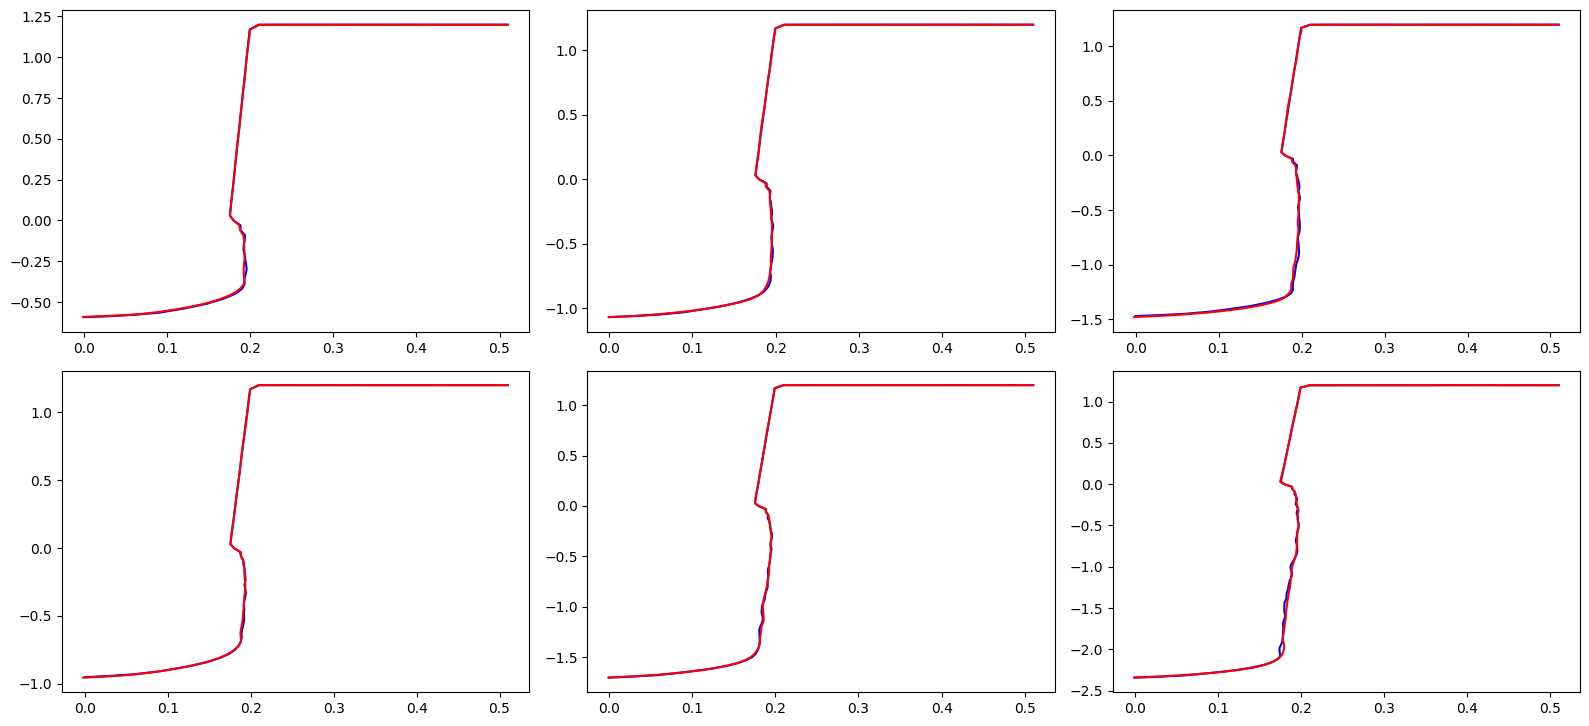

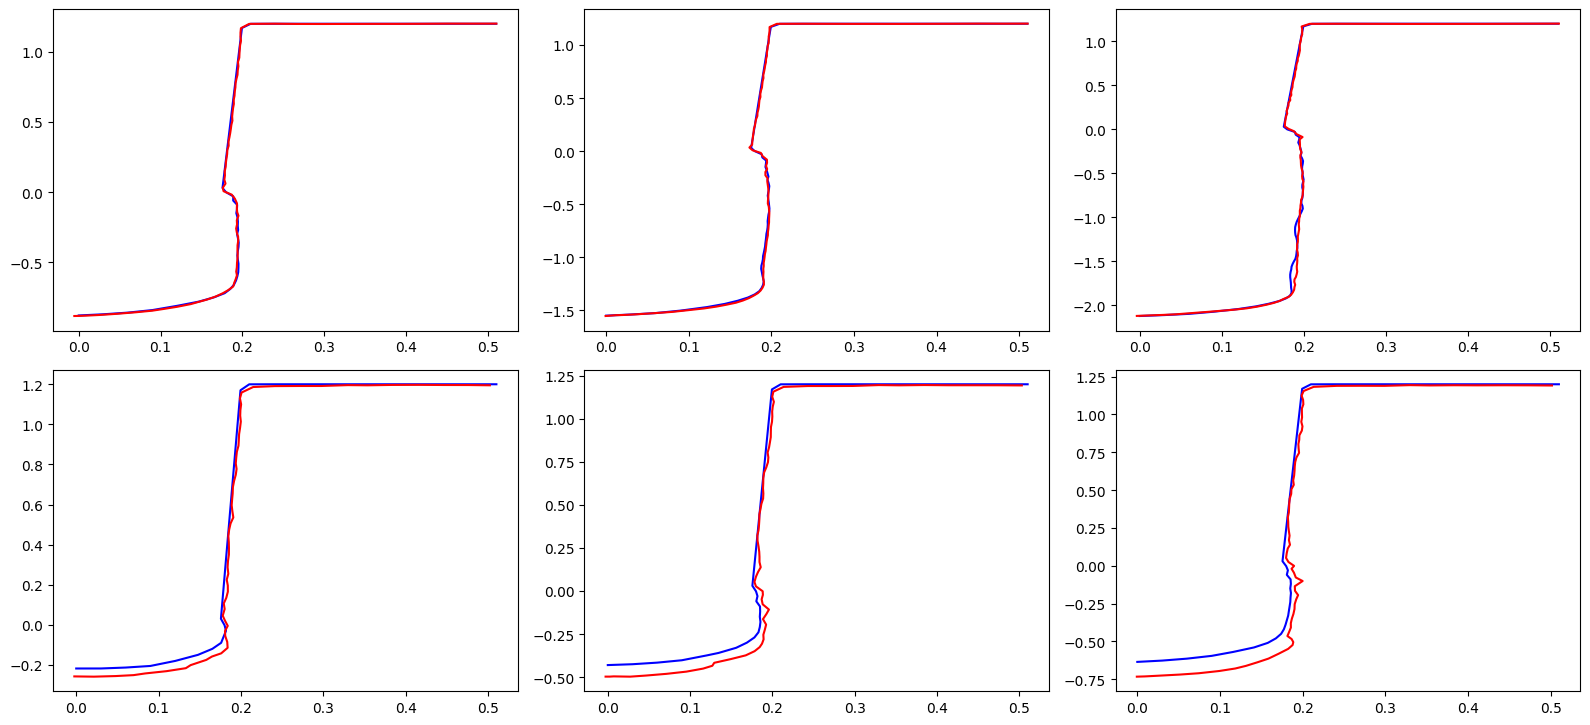

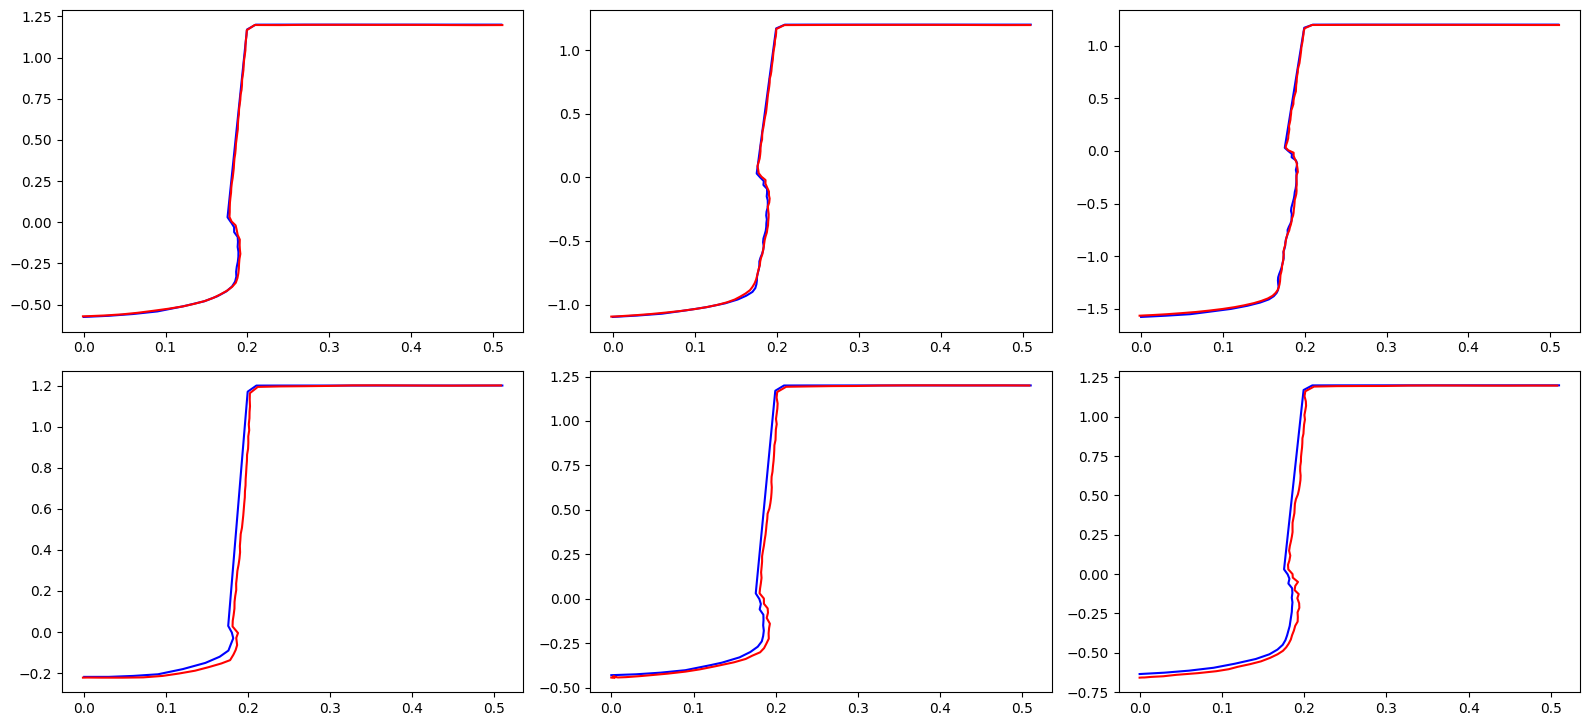

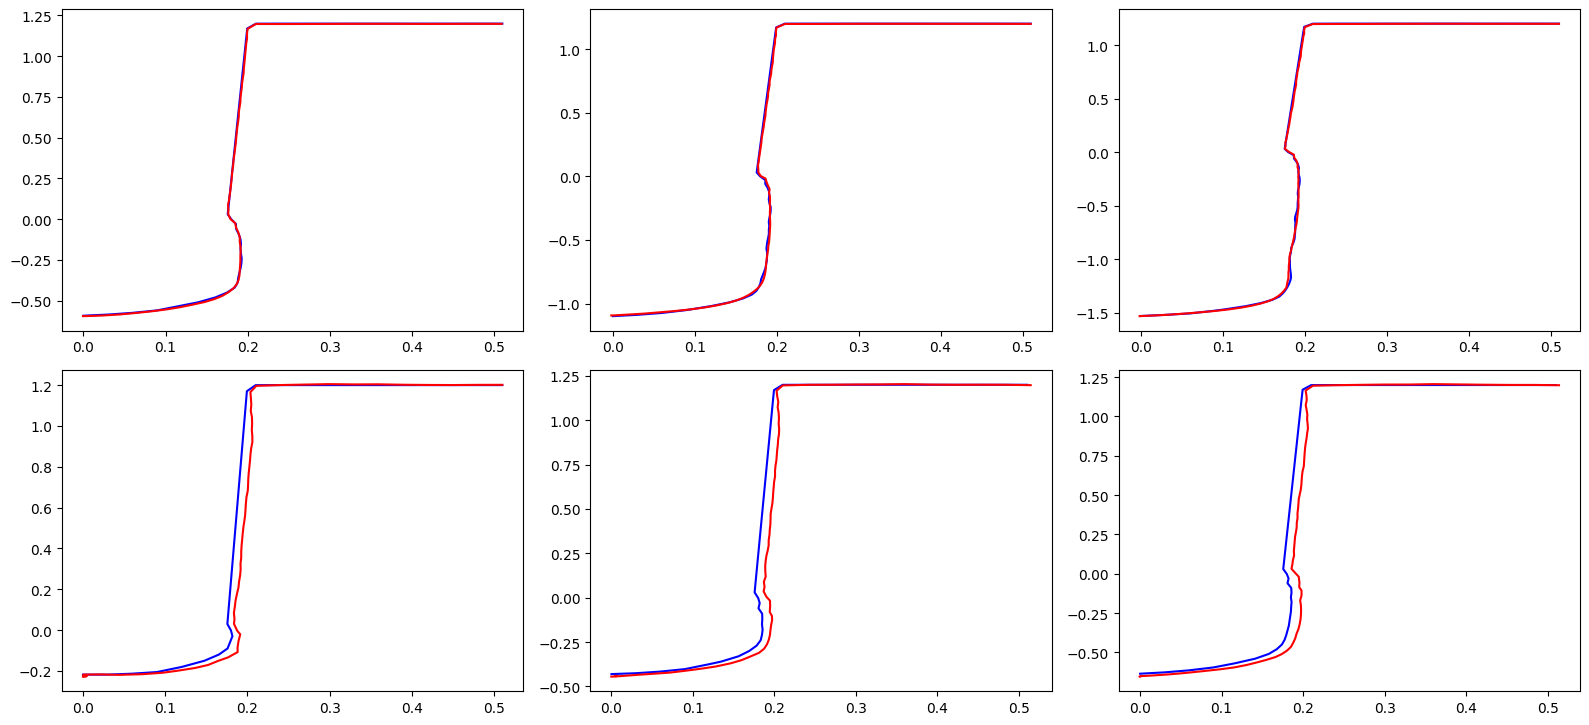

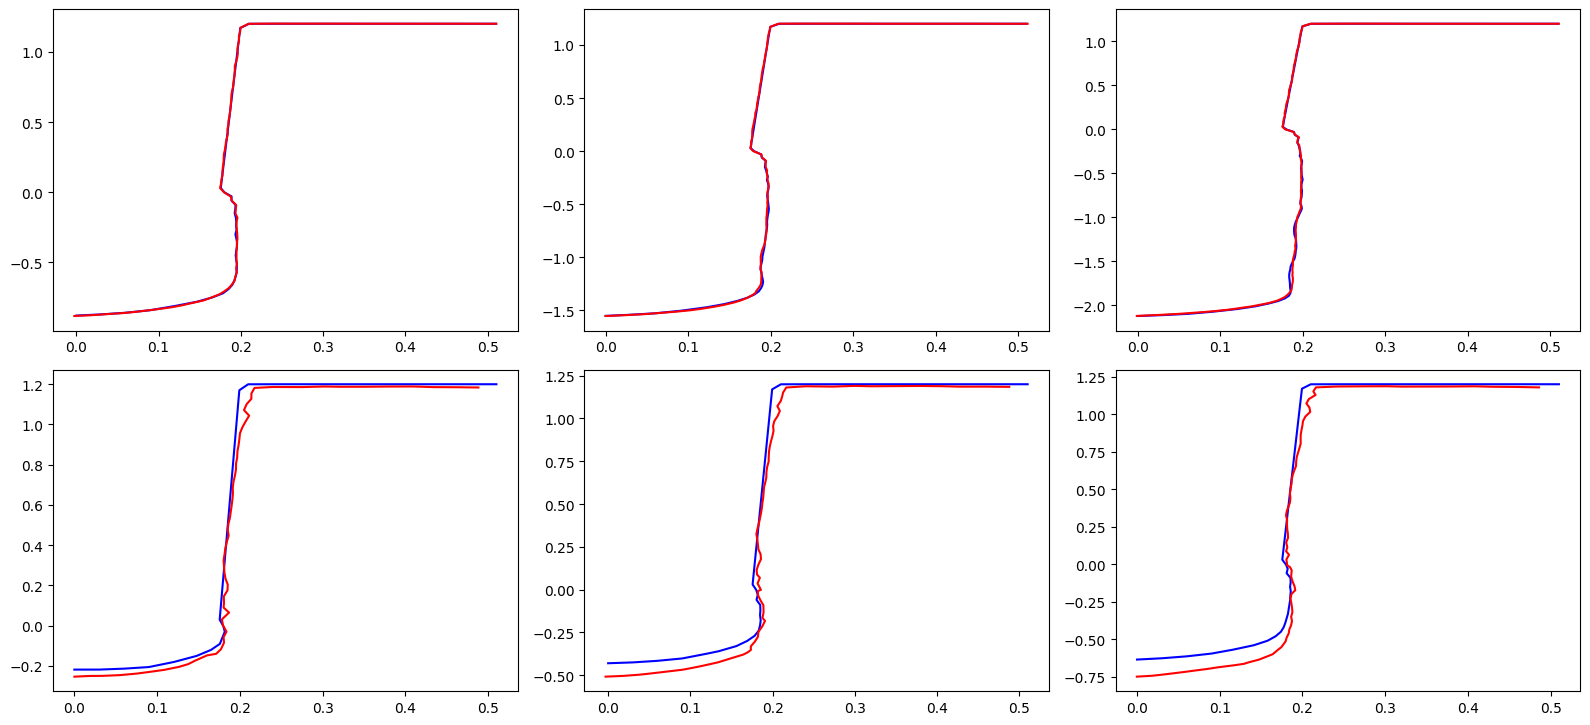

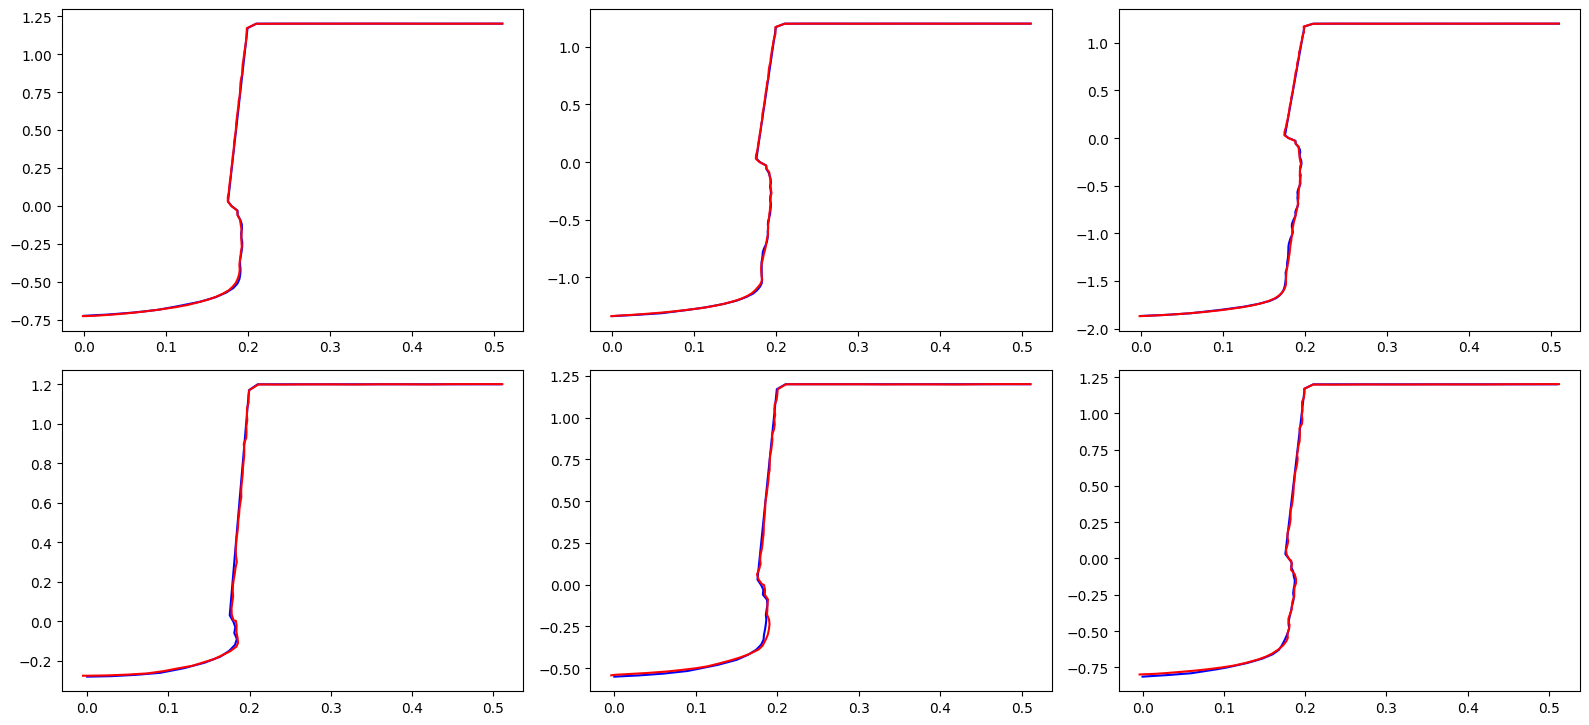

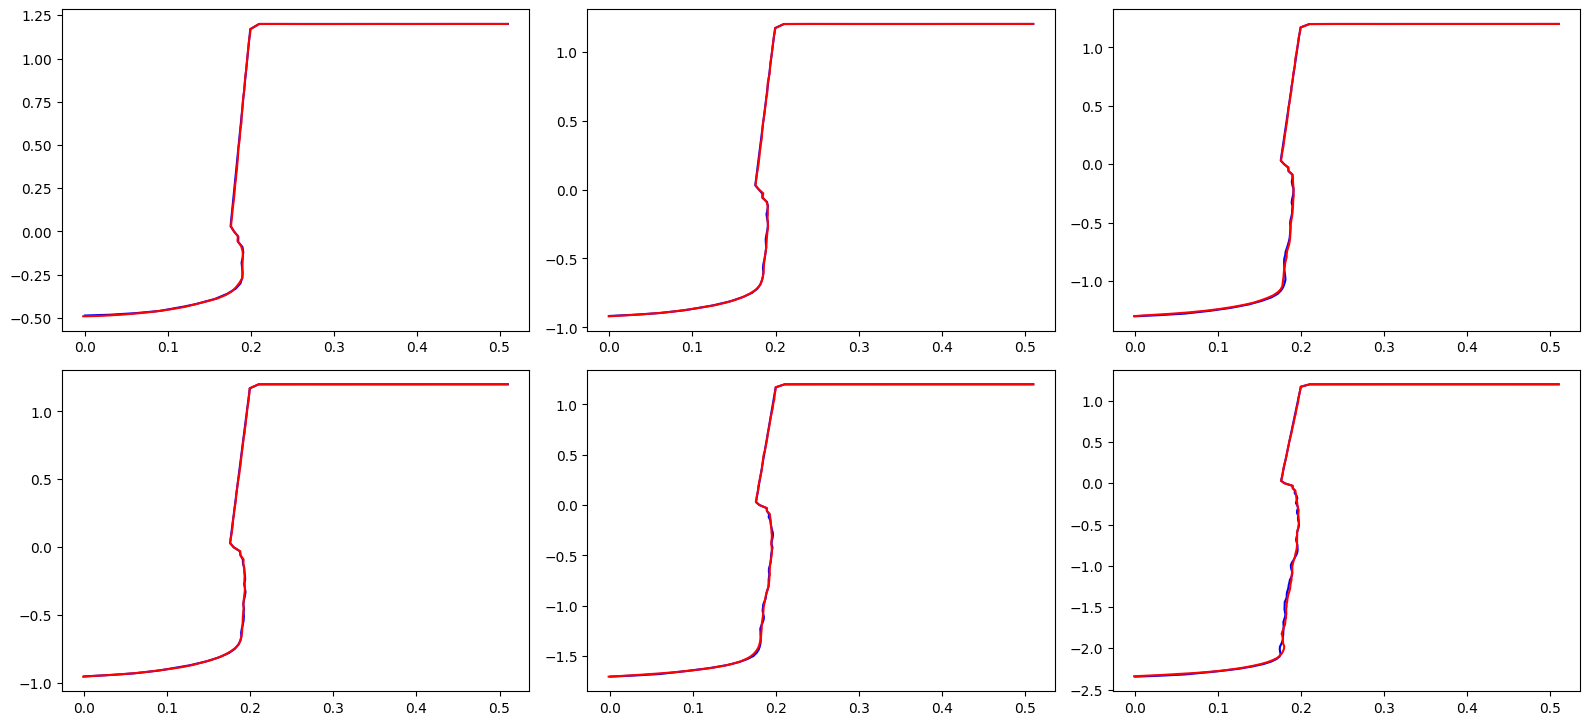

In [4]:
import matplotlib.pyplot as plt
from contextlib import redirect_stdout
sys.path.append("../../")
from pcno.pcno import compute_Fourier_modes, PCNO, PCNO_train
import matplotlib as mpl



def test_normalizer(all_tuple, config, model_n_train,model_train_type):
    x_all,y_all,node_mask,nodes,node_weights,directed_edges,edge_gradient_weights = all_tuple
    x_all_copy = x_all.clone()
    y_all_copy = y_all.clone()    

    normalization_x, normalization_y = config["train"]["normalization_x"], config["train"]["normalization_y"]
    normalization_dim_x, normalization_dim_y = config["train"]["normalization_dim_x"], config["train"]["normalization_dim_y"]
    non_normalized_dim_x, non_normalized_dim_y = config["train"]["non_normalized_dim_x"], config["train"]["non_normalized_dim_y"]

    indices_dict = {'fixradius': np.arange(nodes.shape[0]) % 2 == 0,
                'radius': np.arange(nodes.shape[0]) % 2 == 1,
                'mixed':np.arange(nodes.shape[0])}
    x_train = x_all_copy[indices_dict[model_train_type]][:model_n_train]
    y_train = y_all_copy[indices_dict[model_train_type]][:model_n_train]

    if normalization_x:
        x_normalizer = UnitGaussianNormalizer(x_train, non_normalized_dim = non_normalized_dim_x, normalization_dim=normalization_dim_x)
        x_test = x_normalizer.encode(x_all_copy)
    else:
        x_normalizer = None
        x_test =  x_all_copy
    if normalization_y:
        y_normalizer = UnitGaussianNormalizer(y_train, non_normalized_dim = non_normalized_dim_y, normalization_dim=normalization_dim_y)
        y_test = y_normalizer.encode(y_all_copy)
        y_normalizer.to(device)
    else:
        y_normalizer = None
        y_test = y_all_copy
    test_tuple = (x_test, y_test, node_mask,nodes,node_weights,directed_edges,edge_gradient_weights)

    return test_tuple, y_normalizer

def test_model(model,n_test,test_tuple, y_normalizer):

    x_test,y_test,node_mask,nodes,node_weights,directed_edges,edge_gradient_weights = test_tuple

    rel_l2_fixradius = []
    index_fixradius= []
    rel_l2_radius=[]
    index_radius=[]

    myloss = LpLoss(d=1, p=2, size_average=False)

    with torch.no_grad():
        for i in range(N-n_test,N):
            x, y = x_test[i:i+1].to(device), y_test[i:i+1].to(device)
            aux_batch = (
            node_mask[i:i+1].to(device), nodes[i:i+1].to(device),
            node_weights[i:i+1].to(device), directed_edges[i:i+1].to(device),
            edge_gradient_weights[i:i+1].to(device)
            )
            out = model(x, aux_batch) #.reshape(batch_size_,  -1)
            if y_normalizer:
                out = y_normalizer.decode(out)
                y = y_normalizer.decode(y)
            batch_size_ = x.shape[0]
            out = out * node_mask[i:i+1].to(device) #mask the padded value with 0,(1 for node, 0 for padding)
            test_rel_l2 = myloss(out.view(batch_size_,-1), y.view(batch_size_,-1)).item()
            # test_l2 = myloss.abs(out.view(batch_size_,-1), y.view(batch_size_,-1)).item()

            if i%2==0:
                rel_l2_fixradius.append(test_rel_l2)
                index_fixradius.append(i)
            else :
                rel_l2_radius.append(test_rel_l2)
                index_radius.append(i)
  
         
            # print(f'test index: {i}, test_l2: {test_l2}, test_rel_l2: {test_rel_l2}, test_type: {type_dict[i%3]}')
    return  rel_l2_fixradius,index_fixradius,rel_l2_radius,index_radius

def sorted_result(rel_l2_fixradius,index_fixradius,rel_l2_radius,index_radius):

    fixradius_sorted = sorted(enumerate(rel_l2_fixradius), key=lambda x: x[1], reverse=True)
    radius_sorted = sorted(enumerate(rel_l2_radius), key=lambda x: x[1], reverse=True)


    average_loss_list = [sum(rel_l2_fixradius)/len(rel_l2_fixradius),sum(rel_l2_radius)/len(rel_l2_radius)]
    print('average_rel_l2_of fixradius :  ',round(average_loss_list[0],5) ,flush = True)
    print('average_rel_l2_of radius :  ',round(average_loss_list[1],5))
    print()

    n = 1
    index_fixradius_3 = [index_fixradius[fixradius_sorted[0][0]],index_fixradius[fixradius_sorted[len(fixradius_sorted)//2][0]],index_fixradius[fixradius_sorted[-1][0]]]
    index_radius_3 = [index_radius[radius_sorted[0][0]],index_radius[radius_sorted[len(radius_sorted)//2][0]],index_radius[radius_sorted[-1][0]]]
    for j in range(n):
        print(f'{j+1}th_worst_rel_l2_of fixradius :  ',round(fixradius_sorted[j][1],5), ' index : ',index_fixradius[fixradius_sorted[j][0]])
        print(f'{j+1}th_worst_rel_l2_of radius :  ',round(radius_sorted[j][1],5), ' index : ',index_radius[radius_sorted[j][0]])
        print()
    print('medium_rel_l2_of fixradius : ',round(fixradius_sorted[len(fixradius_sorted)//2][1],5), ' index : ',index_fixradius_3[1])
    print('medium_rel_l2_of radius : ',round(radius_sorted[len(radius_sorted)//2][1],5), ' index : ',index_radius_3[1])
    print()
    for j in range(n):    
        print(f'{j+1}th_best_rel_l2_of fixradius :  ',round(fixradius_sorted[-j-1][1],5), ' index : ',index_fixradius[fixradius_sorted[-j-1][0]])
        print(f'{j+1}th_best_rel_l2_of radius :  ',round(radius_sorted[-j-1][1],5), ' index : ',index_radius[radius_sorted[-j-1][0]])

 
        
    return average_loss_list,index_fixradius_3,index_radius_3

def transform_to_plot(out):
    data=out[0].detach().cpu().numpy()
    # print(data)
    j=0

    x_list=[]
    y_list=[]
    for k in range(3):
        for i in range(len(data)):
            if data[i][2*k]<=1e-4:
                j=i

        # print(len(data))
        # print(j)
        x_list.append(data[j:,2*k])
        y_list.append(data[j:,2*k+1])

    # print(f"x_list={x_list}")
    # print(f"y_list={y_list}")
    return x_list,y_list


def myplot(index_fixradius_3,index_radius_3,save_figure_path,
           model,test_tuple,y_normalizer):

    x_test,y_test,node_mask,nodes,node_weights,directed_edges,edge_gradient_weights = test_tuple
    myloss = LpLoss(d=1, p=2, size_average=False)
    index_dict = {0:index_fixradius_3,1:index_radius_3}
    type_dict = {0:'fixradius',1:"radius"}

    with torch.no_grad():
        for k in range(1):
            index_list = index_dict[k][:-1][::-1]
            test_type = type_dict[k]

            fig, axs = plt.subplots(2, 3, figsize=(16, 8))

                
            for j in range(len(index_list)):
                i = index_list[j]
                x, y = x_test[i:i+1].to(device), y_test[i:i+1].to(device)
                aux_batch = (
                node_mask[i:i+1].to(device), nodes[i:i+1].to(device),
                node_weights[i:i+1].to(device), directed_edges[i:i+1].to(device),
                edge_gradient_weights[i:i+1].to(device)
                )
                out = model(x, aux_batch) #.reshape(batch_size_,  -1)
                if y_normalizer:
                    out = y_normalizer.decode(out)
                    y = y_normalizer.decode(y)
                batch_size_ = x.shape[0]
                out = out*node_mask[i:i+1].to(device) #mask the padded value with 0,(1 for node, 0 for padding)
                test_rel_l2 = myloss(out.view(batch_size_,-1), y.view(batch_size_,-1)).item()


                truth_x_list,truth_y_list=transform_to_plot(y)
                predict_x_list,predict_y_list=transform_to_plot(out)

                axs[j][0].plot(truth_x_list[0],truth_y_list[0],"b-", markersize=2,label="truth")
                axs[j][0].plot(predict_x_list[0],predict_y_list[0],"r-", markersize=2,label="prediction")
                axs[j][1].plot(truth_x_list[1],truth_y_list[1],"b-", markersize=2,label="truth")
                axs[j][1].plot(predict_x_list[1],predict_y_list[1],"r-", markersize=2,label="prediction")
                axs[j][2].plot(truth_x_list[2],truth_y_list[2],"b-", markersize=2,label="truth")
                axs[j][2].plot(predict_x_list[2],predict_y_list[2],"r-", markersize=2,label="prediction")

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()
            if not os.path.exists(save_figure_path):
                os.makedirs(save_figure_path)
            fig.savefig(save_figure_path + f'test_{test_type}.png', format='png', bbox_inches='tight') 
            # fig.savefig(f'train_{model_train_type}_test_{test_type}.pdf', format='pdf', bbox_inches='tight') 
            plt.close(fig)



n_test = 600
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

if True:
    model_train_distribution_list = ['fixradius', 'radius','mixed']
    model_n_train_list =[500,1000,1500]
    model_train_inv_L_scale_list = [False]
else:
    model_train_distribution_list = ['fixradius']  
    model_n_train_list =[1000]  # 500,1000,1500
    model_train_inv_L_scale_list = [False]   



with open('notes/output.txt', 'w') as f:
    with redirect_stdout(f):
        for model_train_distribution in model_train_distribution_list:
            for model_n_train in model_n_train_list:
                for model_train_inv_L_scale in model_train_inv_L_scale_list:

                    # model_path = f'PCNO_holeEtching_model_fixradius.pth'
                    # model_path = f'PCNO_holeEtching_model_{model_train_distribution}_{model_n_train}.pth'
                    model_path=f"model/PCNO_holeEtching_model_{model_train_distribution}_{model_n_train}.pth"
                    save_figure_path = f'figure/pcno_holeEtching_{model_n_train}/{model_train_distribution}_{model_train_inv_L_scale}/'
                    print(model_path)
                    k_max = 32
                    ndim = 1

                    modes = compute_Fourier_modes(ndim, [k_max], [12])
                    modes = torch.tensor(modes, dtype=torch.float).to(device)
                    model = PCNO(ndim, modes, nmeasures=1,
                                layers=[128,128,128,128,128],
                                fc_dim=128,
                                in_dim=x_all.shape[-1], out_dim=y_all.shape[-1],
                                inv_L_scale_hyper = [model_train_inv_L_scale, 0.5, 2.0],
                                act='gelu').to(device)

                    try:
                        checkpoint = torch.load(model_path, map_location=device)
                    except:
                        continue
                    # print(1)
                    model.load_state_dict(checkpoint)
                    
                    print(f'\n\nNew model : n_train = {model_n_train} , equal_weight = {equal_weights} , train_distribution = {model_train_distribution} , train_inv_L_scale = {model_train_inv_L_scale}', flush = True)
                    
                    test_tuple, y_normalizer = test_normalizer(all_tuple, config, model_n_train,model_train_distribution)
                    rel_l2_fixradius,index_fixradius,rel_l2_radius,index_radius = test_model(model, n_test, test_tuple, y_normalizer)
                    average_loss_list,index_fixradius_3,index_radius_3 = sorted_result( rel_l2_fixradius,index_fixradius,rel_l2_radius,index_radius)
                    myplot(index_fixradius_3,index_radius_3,save_figure_path,
                            model,test_tuple, y_normalizer)
                        
                    if model_train_distribution=='mixed' and model_n_train==1000:
                        loss_fixradius = np.array(rel_l2_fixradius)
                        loss_radius = np.array(rel_l2_radius)
                        np.savez('test_result/test_losses.npz', loss_fixradius=loss_fixradius, loss_radius=loss_radius)
                





In [5]:
import re
from collections import defaultdict

def nested_dict():
    return defaultdict(nested_dict)


def parse_file(file_path):
    '''
    data[equalweight][loss_type][n_train][train_type][train_inv_L_scale][test_type]
    datasize:  500, 1000, 1500
    loss_type: average, worst
    train_distribution: fixradius , ...
    train_inv_L_scale: False
    test_type: fixradius, ...
    '''
    with open(file_path, 'r') as file:
        lines = file.readlines()



    data = {}
    data['False'] = {'average':nested_dict(),'worst':nested_dict()}
    data['True'] = {'average':nested_dict(),'worst':nested_dict()}

    model_config = {}
    for line in lines:
        line_split = line.split()
        if line.startswith('New model'):
            for i in range(len(line_split)):
                if line_split[i]=='n_train':
                    model_config['n_train'] = line_split[i+2]
                elif line_split[i]=='equal_weight':
                    model_config['equal_weight'] = line_split[i+2]
                elif line_split[i]=='train_distribution':
                    model_config['train_distribution'] = line_split[i+2]
                elif line_split[i]=='train_inv_L_scale':
                    model_config['train_inv_L_scale'] = line_split[i+2]
        elif model_config and 'average_rel_l2_of' in line_split:
            key = line_split[1]
            value = line_split[3]
            data[model_config['equal_weight']]['average'][model_config['n_train']][model_config['train_distribution']][model_config['train_inv_L_scale']][key] = float(value)

        elif model_config and '1th_worst_rel_l2_of' in line_split:
            key = line_split[1]
            value = line_split[3]
            data[model_config['equal_weight']]['worst'][model_config['n_train']][model_config['train_distribution']][model_config['train_inv_L_scale']][key] = float(value)

    return data


def generate_markdown_table(data, weight, table_type, datasize):
    def format_row(keys, row_data):
        return " | ".join([str(row_data.get(key, '-')) for key in keys])

    header = "| train_distribution | train_inv_L_scale | fixradius | radius |\n"
    format_header = "| :---: | :---: | :---: | :---: | :---: | :---: |\n"

    rows = []
    train_distributions = sorted(data[weight][table_type][datasize].keys())
    columns = ['fixradius', 'radius']

    for train_distribution in train_distributions:
        train_inv_L_scales = sorted(data[weight][table_type][datasize][train_distribution].keys())
        for train_inv_L_scale in train_inv_L_scales:
            row_data = data[weight][table_type][datasize][train_distribution][train_inv_L_scale]
            formatted_row = f"| {train_distribution} | {train_inv_L_scale} | {format_row(columns, row_data)} |"
            rows.append(formatted_row)
    if table_type == 'average':
        title = f'# average loss of datasize {datasize}, equal_weight = {weight}\n'
    elif table_type == 'worst':
        title = f'# biggest loss of datasize {datasize}, equal_weight = {weight}\n'
        
    return title + header + format_header + "\n".join(rows) + "\n\n"


# Parse the input file

parsed_data = parse_file('notes/output.txt')
print(parsed_data)

# Optionally write to files
with open('notes/loss.md', 'w') as f:
    for weight in parsed_data.keys():
        for table_type in parsed_data[weight].keys():
            for datasize in parsed_data[weight][table_type].keys():
                avg_loss_md = generate_markdown_table(parsed_data, weight, table_type, datasize)
                # Print or save to files
                print(avg_loss_md)
                f.write(avg_loss_md)



    


{'False': {'average': defaultdict(<function nested_dict at 0x0000020CD28A6950>, {'500': defaultdict(<function nested_dict at 0x0000020CD28A6950>, {'fixradius': defaultdict(<function nested_dict at 0x0000020CD28A6950>, {'False': defaultdict(<function nested_dict at 0x0000020CD28A6950>, {'fixradius': 0.00644, 'radius': 0.04815})}), 'radius': defaultdict(<function nested_dict at 0x0000020CD28A6950>, {'False': defaultdict(<function nested_dict at 0x0000020CD28A6950>, {'fixradius': 0.0112, 'radius': 0.01229})}), 'mixed': defaultdict(<function nested_dict at 0x0000020CD28A6950>, {'False': defaultdict(<function nested_dict at 0x0000020CD28A6950>, {'fixradius': 0.00756, 'radius': 0.01208})})}), '1000': defaultdict(<function nested_dict at 0x0000020CD28A6950>, {'fixradius': defaultdict(<function nested_dict at 0x0000020CD28A6950>, {'False': defaultdict(<function nested_dict at 0x0000020CD28A6950>, {'fixradius': 0.00543, 'radius': 0.04795})}), 'radius': defaultdict(<function nested_dict at 0x000

In [6]:
import json
with open('test_result/data.json', 'w') as f:
    json.dump(parsed_data, f, indent=4)

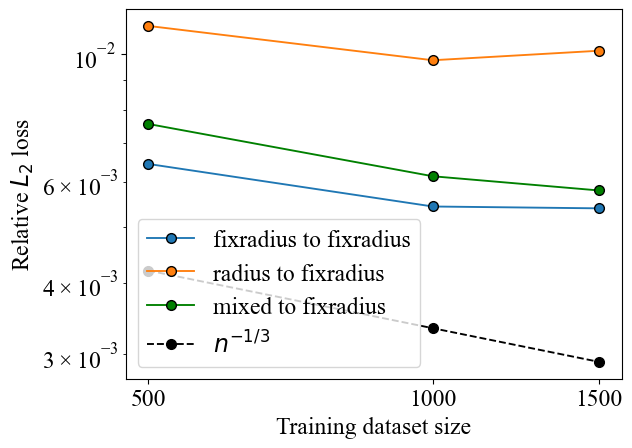

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
import os
import matplotlib.tri as mtri
import matplotlib as mpl

import json
from itertools import product
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 17

with open('test_result/data.json', 'r') as f:
    data = json.load(f)


plot_equal_weights = ['False']   
plot_train_distributions = ['fixradius',"radius",'mixed']   
plot_train_inv_L_scales = ['False']  
plot_test_types = ['fixradius']  
plot_all_lists = [plot_equal_weights, plot_train_distributions, plot_train_inv_L_scales, plot_test_types]

 
x = np.log(np.array([500,1000,1500]))

line_styles = ['-', '-','-', '--']
marker_styles = ['o', 'o', 'o', 'o']
marker_sizes = [7, 7, 7, 7] 

line_colors = ['C0', 'C1', 'g', 'black'] 
marker_face_colors = line_colors 

marker_edge_colors = ['black'] * 4
line_widths = [1.35, 1.35, 1.35,1.35] 
line_label = ['fixradius to fixradius', 'radius to fixradius','mixed to fixradius',r'$n^{-1/3}$'] 



for i,types in enumerate(product(*plot_all_lists)):

    equalweight,train_type,train_inv_L_scale,test_type = types
    loss500 = [data[equalweight]['average']['500'][train_type][train_inv_L_scale][test_type]]
    loss1000 = [data[equalweight]['average']['1000'][train_type][train_inv_L_scale][test_type]]
    loss1500 = [data[equalweight]['average']['1500'][train_type][train_inv_L_scale][test_type]]
    plt.semilogy(x, [loss500, loss1000, loss1500], label = line_label[i], linestyle=line_styles[i], marker=marker_styles[i],
             markersize=marker_sizes[i], markerfacecolor=marker_face_colors[i],
             markeredgecolor=marker_edge_colors[i], color=line_colors[i], linewidth=line_widths[i])
i = -1
loss_ref = np.array([1/500**(1/3), 1/1000**(1/3),1/1500**(1/3)]) / 30
plt.semilogy(x,loss_ref,
             label = line_label[i], linestyle=line_styles[i], marker=marker_styles[i],
             markersize=marker_sizes[i], markerfacecolor=marker_face_colors[i],
             markeredgecolor=marker_edge_colors[i], color=line_colors[i], linewidth=line_widths[i])

plt.legend(loc='best')

# 添加标题和标签
plt.xticks(x,labels = ['500','1000','1500'])
plt.xlabel('Training dataset size')
plt.ylabel('Relative $L_2$ loss')
plt.savefig(f"figure/to_fixradius.png", format="png", dpi=512, bbox_inches="tight")



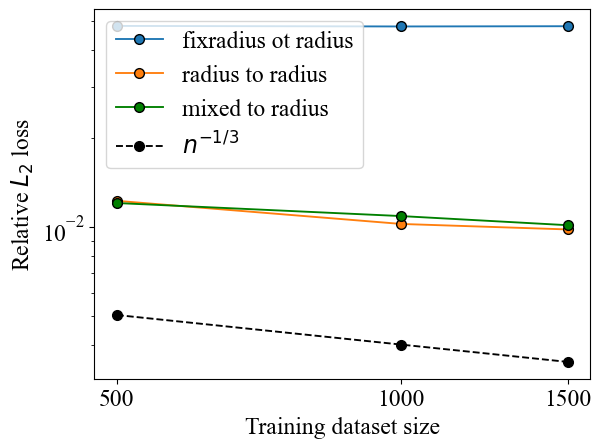

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
import os
import matplotlib.tri as mtri
import matplotlib as mpl

import json
from itertools import product
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 17

with open('test_result/data.json', 'r') as f:
    data = json.load(f)


plot_equal_weights = ['False']   
plot_train_distributions = ['fixradius',"radius",'mixed']   
plot_train_inv_L_scales = ['False']  
plot_test_types = ['radius']  
plot_all_lists = [plot_equal_weights, plot_train_distributions, plot_train_inv_L_scales, plot_test_types]

 
x = np.log(np.array([500,1000,1500]))

line_styles = ['-', '-','-', '--']
marker_styles = ['o', 'o', 'o', 'o']
marker_sizes = [7, 7, 7, 7] 

line_colors = ['C0', 'C1', 'g', 'black'] 
marker_face_colors = line_colors 

marker_edge_colors = ['black'] * 4
line_widths = [1.35, 1.35, 1.35,1.35] 
line_label = ['fixradius ot radius', 'radius to radius','mixed to radius',r'$n^{-1/3}$'] 



for i,types in enumerate(product(*plot_all_lists)):

    equalweight,train_type,train_inv_L_scale,test_type = types
    loss500 = [data[equalweight]['average']['500'][train_type][train_inv_L_scale][test_type]]
    loss1000 = [data[equalweight]['average']['1000'][train_type][train_inv_L_scale][test_type]]
    loss1500 = [data[equalweight]['average']['1500'][train_type][train_inv_L_scale][test_type]]
    plt.semilogy(x, [loss500, loss1000, loss1500], label = line_label[i], linestyle=line_styles[i], marker=marker_styles[i],
             markersize=marker_sizes[i], markerfacecolor=marker_face_colors[i],
             markeredgecolor=marker_edge_colors[i], color=line_colors[i], linewidth=line_widths[i])
i = -1
loss_ref = np.array([1/500**(1/3), 1/1000**(1/3),1/1500**(1/3)]) / 25
plt.semilogy(x,loss_ref,
             label = line_label[i], linestyle=line_styles[i], marker=marker_styles[i],
             markersize=marker_sizes[i], markerfacecolor=marker_face_colors[i],
             markeredgecolor=marker_edge_colors[i], color=line_colors[i], linewidth=line_widths[i])

plt.legend(loc='best')

# 添加标题和标签
plt.xticks(x,labels = ['500','1000','1500'])
plt.xlabel('Training dataset size')
plt.ylabel('Relative $L_2$ loss')
plt.savefig(f"figure/to_radius.png", format="png", dpi=512, bbox_inches="tight")



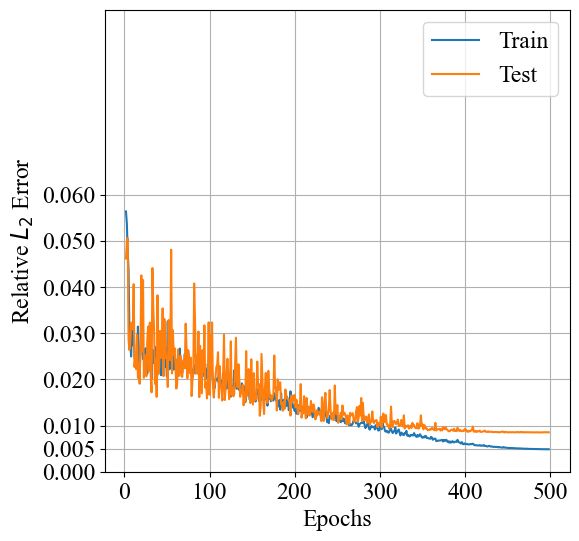

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
import os
import matplotlib.tri as mtri
import matplotlib as mpl
import json
from itertools import product
from matplotlib.ticker import FixedLocator, FixedFormatter

file = np.genfromtxt("log/pcno_holeEtching_mixed_1000.log", skip_header = 6)

train_loss = file[:,10]
test_loss = file[:,16]

iterations = np.arange(0,499)
fig, ax = plt.subplots(figsize=(6,6))
T=2
ax.plot(iterations[T:], train_loss[T:], label='Train')
ax.plot(iterations[T:], test_loss[T:], label='Test')
ax.grid("on")

ax.set_xlabel('Epochs')
ax.set_ylabel('Relative $L_2$ Error')

extra_ticks = np.array((0.005,)) 


default_ticks = ax.get_yticks()

all_ticks = np.sort(np.unique(np.concatenate((default_ticks, extra_ticks))))
# 

ax.yaxis.set_major_locator(FixedLocator(all_ticks))

ax.yaxis.set_major_formatter(FixedFormatter([f'{tick:.3f}' for tick in all_ticks]))

legend = ax.legend()

ax.set_ylim(bottom=0,top = 0.1)
plt.savefig(f"figure/losses_epoch.png", format="png", dpi=512, bbox_inches="tight")

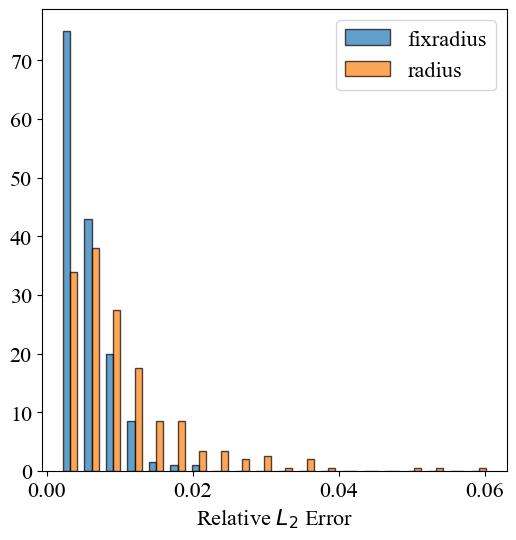

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
import os
import matplotlib.tri as mtri
import matplotlib as mpl
import json
from itertools import product
from matplotlib.ticker import FixedLocator, FixedFormatter

err = np.load('test_result/test_losses.npz')
all_error = np.hstack((err['loss_fixradius'],err['loss_radius']))

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 16

hist, bin_edges = np.histogram(all_error, bins=20, density=False)
# print(hist) 
# print(bin_edges)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


fig, ax = plt.subplots(figsize=(6, 6))
hist_fixradius,  a  = np.histogram(err['loss_fixradius'], bins=bin_edges, density=False)
hist_radius, a = np.histogram(err['loss_radius'], bins=bin_edges, density=False)

hist_percent_fixradius   = (hist_fixradius / 200) * 100
hist_percent_radius   = (hist_radius / 200) * 100


width = np.diff(bin_edges)[0]
ax.bar(bin_centers - width/3, hist_percent_fixradius, width=width/3, label='fixradius', edgecolor='black', alpha=0.7, color='C0')
ax.bar(bin_centers, hist_percent_radius, width=width/3, label='radius', edgecolor='black', alpha=0.7, color='C1')

ax.legend()
ax.set_xlabel('Relative $L_2$ Error')
# plt.show()
plt.savefig(f"figure/loss_distribution.png", format="png", dpi=512, bbox_inches="tight")